In [187]:
#Importando as Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

## Fase 1: Análise Exploratória de Dados

In [188]:
#Leitura do arquivo .csv salvo localmente e atribuição ao DataFrame nomeando de "df"
df = pd.read_csv("credit_risk_dataset.csv")
print ('Dados importados com sucesso no arquivo local!')

Dados importados com sucesso no arquivo local!


In [189]:
print(" ----- ANÁLISE EXPLORTÓRIA VALORES-----")

#Dimensões do DataFrame:
print(f"\n1. Dimensões do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")

#Tipo de cada variável:
print("\n2. Tipos de cada variável:")
print(df.dtypes)

#Resumo estatistico:
print("\n3. Resumo Estatístico das Variáveis Numéricas:")
display(df.describe())

#Visualizando as primeiras 5 linhas:
print("\n4. Visualizando a estrutura inicial dos dados:")
display(df.head(5))

#Alvo do estudo:
print("\n5. Significado da coluna alvo loan_status:")
print("loan_status = 1 --> Inadimplente")
print("loan_status = 0 --> Bom pagador")


 ----- ANÁLISE EXPLORTÓRIA VALORES-----

1. Dimensões do Dataset: 32581 linhas e 12 colunas.

2. Tipos de cada variável:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

3. Resumo Estatístico das Variáveis Numéricas:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



4. Visualizando a estrutura inicial dos dados:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



5. Significado da coluna alvo loan_status:
loan_status = 1 --> Inadimplente
loan_status = 0 --> Bom pagador


In [190]:
#Validação de dados do Pearson_age:
idade_maxima = df['person_age'].max()
idade_minima = df['person_age'].min()
idade_alta= (df['person_age'] > 110).sum()

print(idade_maxima)
print(idade_minima)
print(idade_alta)

144
20
5


In [191]:
#Validação e dados person_emp_lenght:
sem_emprestimo = (df['person_emp_length'] == 0).sum()
print(sem_emprestimo)

4105


In [192]:
#Validação e dados person_emp_lenght:
sem_emprestimo2 = (df['loan_percent_income'] == 0).sum()
print(sem_emprestimo2)

9


 ----- ANÁLISE EXPLORTÓRIA GRÁFICOS-----

6. Histograma de idade:


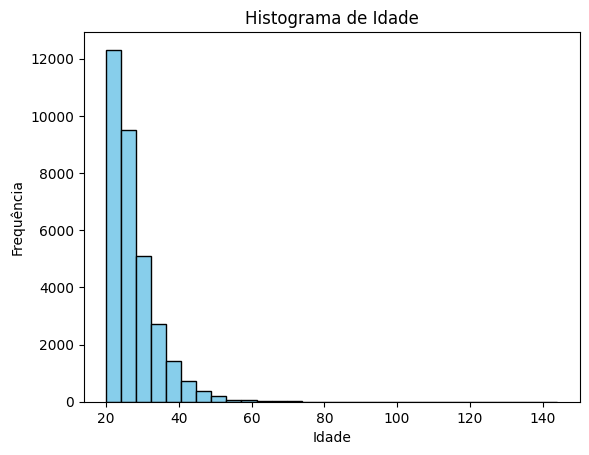


7. Desbalanceamento da Variável Alvo:


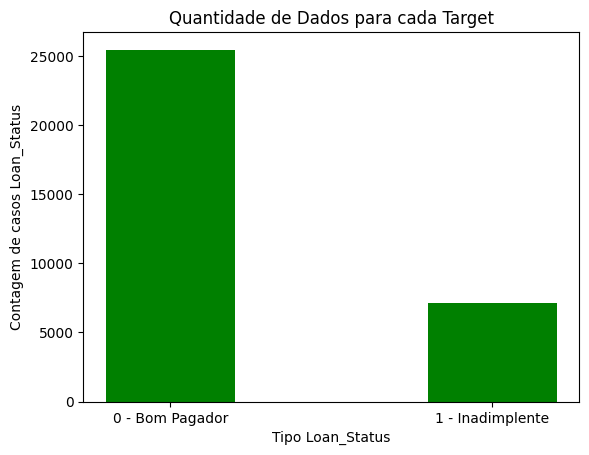


8. Mapa de calor de correlação de Pearson:


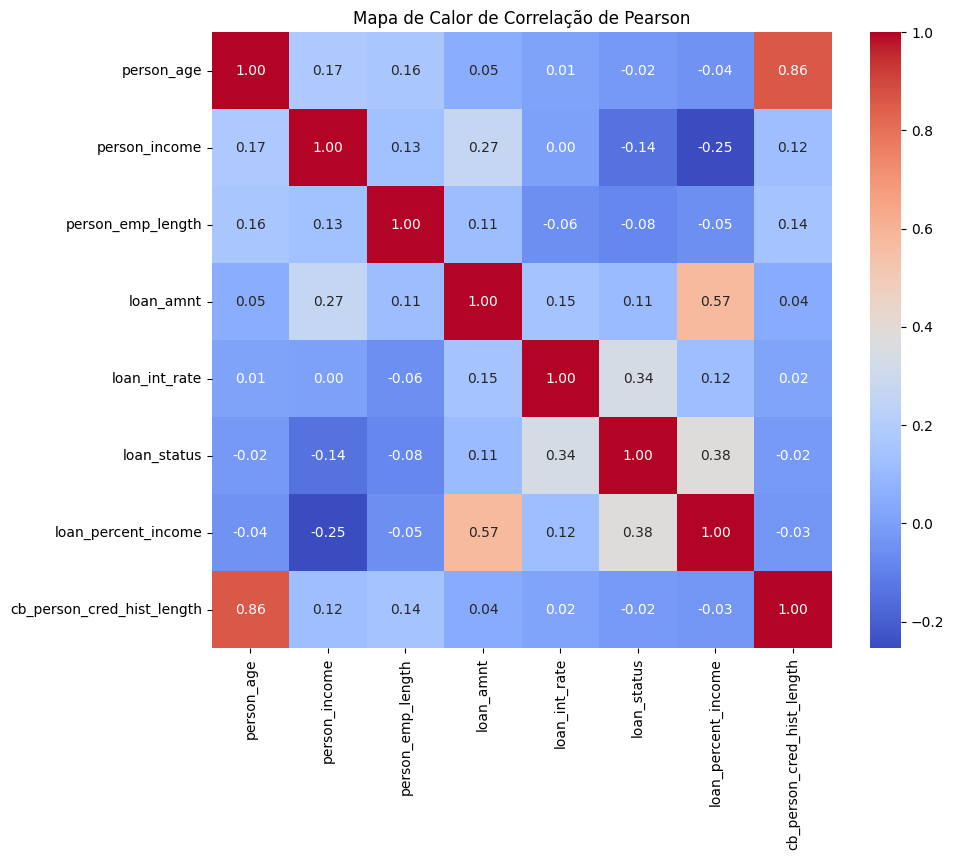

In [193]:
print(" ----- ANÁLISE EXPLORTÓRIA GRÁFICOS-----")
#Histograma de idade:
print("\n6. Histograma de idade:")
plt.hist(df["person_age"],bins=30,color='skyblue',edgecolor='black')
plt.title("Histograma de Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

#Desbalanceamento da variavel alvo:
print("\n7. Desbalanceamento da Variável Alvo:")
contagem_loan_status = df['loan_status'].value_counts().sort_index()
plt.bar(['0 - Bom Pagador', '1 - Inadimplente'], contagem_loan_status, color='green', width=0.4)
plt.title("Quantidade de Dados para cada Target")
plt.ylabel('Contagem de casos Loan_Status')
plt.xlabel('Tipo Loan_Status')
plt.show()

#Correlação de Pearson:
print("\n8. Mapa de calor de correlação de Pearson:")
corr_matrix = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor de Correlação de Pearson")
plt.show()

Resultado da Fase 1:
  

*   O valor máximo para pearson_age deu 144 anos. Oque e muito acima da espectativa de vida. Investigando melhor, temos 5 casos a cima de 110 anos. Oque não me parece muito coerente.

* Sobre o "person_emp_lenght" os valores com ZERO aparecem 4105 vezes, oque pode significar que a pessoa não conseguiu o emprestimo então não tem como avaliar se ela é um risco pra conceder crédito ou não.
O mesmo para pessoas em que o "loan_percent_income" é ZERO que aparece 9 vezes. Oque significa que essas pessoas provavelmente não pegaram o emprestimo ou não tem renda pra pegar.

*   Sobre o histograma aparenta ter uma maior frequencia de pessoas mais novas pedindo emprestimos e financiamentos.
*   Sobre a quantidade de valores de target para a situação 1 e 0 notamos que temos muitos dados de bons pagadores e poucos de pessoas inadimplentes. Então está desbalanceado.


*   Correlações fortes (relevantes):
1.   person_age e cb_person_cred_hist_length = 0.86 — pessoas mais velhas têm histórico de crédito mais longo.

2.   loan_amnt e loan_percent_income = 0.57 — empréstimos maiores comprometem mais a renda.

3. loan_percent_income e loan_status = 0.38 — quem compromete mais renda com o empréstimo tende mais a inadimplir.

* Correlações fracas (variáveis pouco relacionadas):

1. person_income e loan_status = -0.14 — renda tem correlação muito fraca com inadimplência. Ou seja, não importa muito quanto a pessoa ganha e mais o % da renda dela que está destinada ao emprestimo.


## Fase 2: Tratamento e Limpeza de Dados


1. Contagem de Valores Nulos (NaN) ANTES do tratamento:
person_emp_length     895
loan_int_rate        3116
dtype: int64

2. Contagem de Valores Nulos (NaN) DEPOIS do tratamento: Tudo zerado!
Series([], dtype: int64)

3. Contagem de Linhas Duplicadas ANTES do tratamento:
157

4. Contagem de Linhas Duplicadas DEPOIS do tratamento:Tudo Zerado!
0

5. Contagem de pessoas a cima de 110 anos ANTES do tratamento:
5

6. Contagem de pessoas a cima de 110 anos DEPOIS do tratamento:
0

7. Contagem de pessoas que não conseguiram/contrataram o emprestimo ANTES do tratamento:
4086

8. Contagem de pessoas que não conseguiram/contrataram o emprestimo DEPOIS do tratamento:
0

9. Análise Estatística de Outliers...


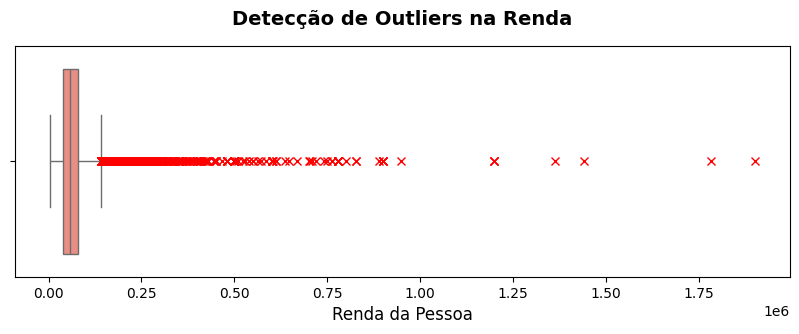


10. Base filtrada para rendas normal (Abaixo de $ 500.000)
Novo tamanho: 27385 linhas.


In [194]:
#Remover Valores Nulos:
print("\n1. Contagem de Valores Nulos (NaN) ANTES do tratamento:")
print(df.isna().sum()[df.isna().sum() > 0])

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mean())  #loan_int_rate -> Como as taxas de juros segundo .describe() tem std relativamente baixo. Vamos trocar os valores pela media.
df = df[df['person_emp_length'].notna()] #perso_emp_length -> Vamos exluir esses dados sem valores.

print("\n2. Contagem de Valores Nulos (NaN) DEPOIS do tratamento: Tudo zerado!")
print(df.isna().sum()[df.isna().sum() > 0])

#Remover linhas duplicadas:
print("\n3. Contagem de Linhas Duplicadas ANTES do tratamento:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\n4. Contagem de Linhas Duplicadas DEPOIS do tratamento:Tudo Zerado!")
print(df.duplicated().sum())

#Remover person_age a cima de 110 anos:
print("\n5. Contagem de pessoas a cima de 110 anos ANTES do tratamento:")
print((df['person_age'] > 110).sum())

df = df[df['person_age'] <= 110] #Remover pessoas com idades muito alta (que provavelmente é um erro dado a espectativa de vida)

print("\n6. Contagem de pessoas a cima de 110 anos DEPOIS do tratamento:")
print((df['person_age'] > 110).sum())

#Remover person_emp_length com valor ZERO:
print("\n7. Contagem de pessoas que não conseguiram/contrataram o emprestimo ANTES do tratamento:")
print((df['person_emp_length'] == 0).sum())

df = df[df['person_emp_length'] != 0] #Remover aqueles que "pegaram o emprestimo" com prazo de 0 meses

print("\n8. Contagem de pessoas que não conseguiram/contrataram o emprestimo DEPOIS do tratamento:")
print((df['person_emp_length'] == 0).sum())

#Tratamento de Outiers:
print("\n9. Análise Estatística de Outliers...")
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['person_income'], color='salmon', flierprops={"marker": "x", "markeredgecolor": "red"})
plt.title("Detecção de Outliers na Renda", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Renda da Pessoa", fontsize=12)
plt.show()

#Estamos com alguns valores de renda muito alta, até 6 milhões. Vamos reduzir pra abaixo de 500.000 para ser mais coerente.
df = df[df['person_income'] < 500000]
print(f"\n10. Base filtrada para rendas normal (Abaixo de $ 500.000)")

print(f"Novo tamanho: {df.shape[0]} linhas.")


## Fase 3: Feature Engineering

In [195]:
#Criar coluna comprometimento_renda = (loan_amnt / person_income) * 100.
#Dados NaN não tem pois já eliminei no tratamento de dados

#1. Verificar se não há valores zerados em loan_amnt senão o cálculo vai retornar erro
valor_emprestimo_zero = (df['loan_amnt'] == 0).sum()
print("\n1. Contagem loan_amnt zerados:")
print(valor_emprestimo_zero)

#2. Verificar se não há valores zerados em person_income senão o cálculo vai retornar erro
renda_zerada = (df['person_income'] == 0).sum()
print("\n2. Contagem person_income zerados:")
print(renda_zerada)

df['comprometimento_renda'] = df["loan_amnt"] / df["person_income"] * 100
df['comprometimento_renda'] = df['comprometimento_renda'].fillna(0)
print("Nova coluna comprometimento_renda criada com sucesso!")

df.describe()


1. Contagem loan_amnt zerados:
0

2. Contagem person_income zerados:
0
Nova coluna comprometimento_renda criada com sucesso!


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda
count,27385.000000,27385.000000,27385.000000,27385.000000,27385.000000,27385.000000,27385.000000,27385.000000,27385.000000
mean,27.727004,66403.283549,5.499909,9823.106628,11.017703,0.206682,0.169362,5.809239,16.974341
std,6.166384,40861.663507,3.973530,6384.310591,3.082264,0.404933,0.105900,4.037110,10.621214
min,20.000000,4200.000000,1.000000,500.000000,5.420000,0.000000,0.010000,2.000000,0.500000
25%,23.000000,40000.000000,3.000000,5000.000000,8.490000,0.000000,0.090000,3.000000,8.936550
50%,26.000000,57000.000000,5.000000,8200.000000,11.011695,0.000000,0.150000,4.000000,14.707613
75%,30.000000,80000.000000,7.000000,13000.000000,13.110000,0.000000,0.230000,8.000000,22.727273
max,94.000000,499800.000000,123.000000,35000.000000,23.220000,1.000000,0.780000,30.000000,77.708333


## Fase 4: Separação, balanceamento e escalonamento seguro

In [196]:
#Traduzir todo o contexto humano (texto) para formato numérico:

#Categorias em que a ordem não importa -> #DUMMIFICAÇÃO / ONE-HOT ENCODING:
df_pronto = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'cb_person_default_on_file'], drop_first=True) #cria novas colunas com valores de verdadeiro e falso

#Categorias em que a orde importa -> CODIFICAÇÃO ORDINAL:

# Dicionario para criação do peso (ordem):
dicionario_tamanho = {'A': 0,
                      'B': 1,
                      'C': 2,
                      'D': 3,
                      'E': 4,
                      'F': 5,
                      'G': 6}

df_pronto['loan_grade'] = df_pronto['loan_grade'].map(dicionario_tamanho)# A função map substitui o texto pelo número correspondente instantaneamente

display(df_pronto.head(5))
display(df_pronto.info())
print(f"Colunas saltaram para {df_pronto.shape[1]} após criar os 'interruptores' 0 e 1.")


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,22,59000,123.0,3,35000,16.02,1,0.59,3,59.322034,False,False,True,False,False,False,True,False,True
1,21,9600,5.0,1,1000,11.14,0,0.10,2,10.416667,False,True,False,True,False,False,False,False,False
2,25,9600,1.0,2,5500,12.87,1,0.57,3,57.291667,False,False,False,False,False,True,False,False,False
3,23,65500,4.0,2,35000,15.23,1,0.53,2,53.435115,False,False,True,False,False,True,False,False,False
4,24,54400,8.0,2,35000,14.27,1,0.55,4,64.338235,False,False,True,False,False,True,False,False,True


<class 'pandas.core.frame.DataFrame'>
Index: 27385 entries, 0 to 32580
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   27385 non-null  int64  
 1   person_income                27385 non-null  int64  
 2   person_emp_length            27385 non-null  float64
 3   loan_grade                   27385 non-null  int64  
 4   loan_amnt                    27385 non-null  int64  
 5   loan_int_rate                27385 non-null  float64
 6   loan_status                  27385 non-null  int64  
 7   loan_percent_income          27385 non-null  float64
 8   cb_person_cred_hist_length   27385 non-null  int64  
 9   comprometimento_renda        27385 non-null  float64
 10  person_home_ownership_OTHER  27385 non-null  bool   
 11  person_home_ownership_OWN    27385 non-null  bool   
 12  person_home_ownership_RENT   27385 non-null  bool   
 13  loan_intent_EDUCATION

None

Colunas saltaram para 19 após criar os 'interruptores' 0 e 1.


In [197]:
#Split de Dados:

print("Separando em Treino e Teste:")

# Vamos prever o loan_status -> O 'y' é o target (loan_status), o 'X' é o feature (todo o resto)
X = df_pronto.drop(columns=['loan_status'])
y = df_pronto['loan_status']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Dados de Treino: {X_treino.shape[0]} para estudar.")
print(f"Dados de Teste: {X_teste.shape[0]} para a prova final.")

Separando em Treino e Teste:
Dados de Treino: 21908 para estudar.
Dados de Teste: 5477 para a prova final.


In [198]:
#Balanceamento de Classes (Técnicas de Reamostragem) -> Aplicado estritamente e apenas nos dados de Treino.

# Aplicando O SMOTE (GERAÇÃO INTELIGENTE DE DADOS SINTÉTICOS) -> rica em variedade, onde a máquina pode realmente estudar padrões sem decorar nada.
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_treino, y_treino)

print(f" Classe 0 (Leituras Normais Reais):  {y_smote.value_counts()[0]} amostras")
print(f" Classe 1 (Falhas Reais + Sintéticas): {y_smote.value_counts()[1]} amostras (Equilíbrio Matemático Perfeito!)")

#Porque não?
# Undersampling -> Não seria bom porque se olharmos os dados originais reduziriamos para um pouco mais de 6000 a nossa base de dados.
# Oversampling -> A IA pode decorar o "Inadimplente" e não ver realmente se a pessoa é.

 Classe 0 (Leituras Normais Reais):  17380 amostras
 Classe 1 (Falhas Reais + Sintéticas): 17380 amostras (Equilíbrio Matemático Perfeito!)


In [199]:
#Escalonamento Seguro:

# Escalonar para o KNN (usando StandardScaler):
#(fit_transform no treino balanceado e transform no teste).
# Escalonamento correto — aplicar sobre os dados já balanceados:
scaler = StandardScaler()
X_smote_escalonado = scaler.fit_transform(X_smote)
X_teste_escalonado = scaler.transform(X_teste)

# Não Escalonar para a Árvore de Decisão:


## Fase 5: Modelagem e Validação

### KNN:

In [200]:
# KNN (K-Nearest Neighbors) (K = 3, 5, 7 e 9) -> Preferi repetir as linhas (já que não eram muitas) para ficar mais claro que foi feito pra todas os K

# Treino — usar X e y do SMOTE - ESCALONADO:
knn_model_3 = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_model_3.fit(X_smote_escalonado, y_smote)

knn_model_5 = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_model_5.fit(X_smote_escalonado, y_smote)

knn_model_7 = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn_model_7.fit(X_smote_escalonado, y_smote)

knn_model_9 = KNeighborsClassifier(n_neighbors=9, metric='euclidean')
knn_model_9.fit(X_smote_escalonado, y_smote)

print("Modelos KNN (K-Nearest Neighbors) para (K = 3, 5, 7 e 9) treinados com sucesso!")

# Colocando os modelos à prova no Mundo Real (Base de Teste)
previsoes_knn_3 = knn_model_3.predict(X_teste_escalonado)
previsoes_knn_5 = knn_model_5.predict(X_teste_escalonado)
previsoes_knn_7 = knn_model_7.predict(X_teste_escalonado)
previsoes_knn_9 = knn_model_9.predict(X_teste_escalonado)

Modelos KNN (K-Nearest Neighbors) para (K = 3, 5, 7 e 9) treinados com sucesso!


In [201]:
# Comparativo de Relatórios Numéricos
print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: KNN - K = 3")
print(classification_report(y_teste, previsoes_knn_3))

print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: KNN - K = 5")
print(classification_report(y_teste, previsoes_knn_5))

print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: KNN - K = 7")
print(classification_report(y_teste, previsoes_knn_7))

print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: KNN - K = 9")
print(classification_report(y_teste, previsoes_knn_9))


RELATÓRIO DE DESEMPENHO: KNN - K = 3
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      4345
           1       0.64      0.68      0.66      1132

    accuracy                           0.85      5477
   macro avg       0.78      0.79      0.78      5477
weighted avg       0.86      0.85      0.86      5477


RELATÓRIO DE DESEMPENHO: KNN - K = 5
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      4345
           1       0.66      0.69      0.67      1132

    accuracy                           0.86      5477
   macro avg       0.79      0.80      0.79      5477
weighted avg       0.86      0.86      0.86      5477


RELATÓRIO DE DESEMPENHO: KNN - K = 7
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      4345
           1       0.68      0.69      0.69      1132

    accuracy                           0.87      5477
   macro avg  

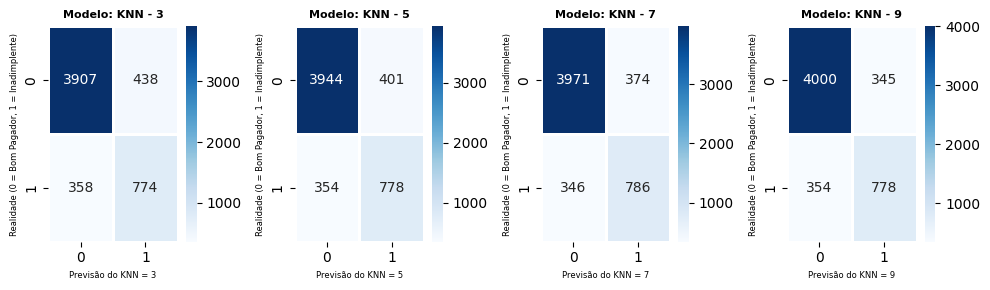

In [202]:
# Criando uma figura grande para colocar os dois gráficos lado a lado
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

# ---- Matriz do KNN 3 ----
matriz_knn_3 = confusion_matrix(y_teste, previsoes_knn_3)
sns.heatmap(matriz_knn_3, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=1)
axes[0].set_title('Modelo: KNN - 3', fontsize=8, fontweight='bold')
axes[0].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[0].set_xlabel('Previsão do KNN = 3', fontsize=6)

# ---- Matriz do KNN 5 ----
matriz_knn_5 = confusion_matrix(y_teste, previsoes_knn_5)
sns.heatmap(matriz_knn_5, annot=True, fmt='d', cmap='Blues', ax=axes[1], linewidths=1)
axes[1].set_title('Modelo: KNN - 5', fontsize=8, fontweight='bold')
axes[1].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[1].set_xlabel('Previsão do KNN = 5', fontsize=6)

# ---- Matriz do KNN 7 ----
matriz_knn_7 = confusion_matrix(y_teste, previsoes_knn_7)
sns.heatmap(matriz_knn_7, annot=True, fmt='d', cmap='Blues', ax=axes[2], linewidths=1)
axes[2].set_title('Modelo: KNN - 7', fontsize=8, fontweight='bold')
axes[2].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[2].set_xlabel('Previsão do KNN = 7', fontsize=6)

# ---- Matriz do KNN 9 ----
matriz_knn_9 = confusion_matrix(y_teste, previsoes_knn_9)
sns.heatmap(matriz_knn_9, annot=True, fmt='d', cmap='Blues', ax=axes[3], linewidths=1)
axes[3].set_title('Modelo: KNN - 9', fontsize=8, fontweight='bold')
axes[3].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[3].set_xlabel('Previsão do KNN = 9', fontsize=6)

# Ajustar o layout e exibir na tela
plt.tight_layout()
plt.show()

In [213]:
# Diagnóstico de overfitting — comparar treino vs teste
print("Treino:", classification_report(y_smote, knn_model_9.predict(X_smote_escalonado)))
print("Teste:", classification_report(y_teste, previsoes_knn_9))

Treino:               precision    recall  f1-score   support

           0       0.88      0.94      0.91     17380
           1       0.93      0.88      0.90     17380

    accuracy                           0.91     34760
   macro avg       0.91      0.91      0.91     34760
weighted avg       0.91      0.91      0.91     34760

Teste:               precision    recall  f1-score   support

           0       0.92      0.92      0.92      4345
           1       0.69      0.69      0.69      1132

    accuracy                           0.87      5477
   macro avg       0.81      0.80      0.80      5477
weighted avg       0.87      0.87      0.87      5477



Resultado do KNN:

De todos os testes com KNN, o que mais se destaca é o K=9 com acurácia de 87% e maior precisão 69%.

Mas mesmo assim não ficou boa essa precisão.

Com um recall da classe 1 como esse, o modelo deixa escapar 31% dos inadimplentes reais.
Oque é um problema. O SMOTE ajudou mas não deixou essa ML muito boa.




### Árvore de Decisão:

In [203]:
# Arvore de Decisão (profundidades 3, 5, 7 e ilimitada/None) -> Preferi repetir as linhas (já que não eram muitas) para ficar mais claro que foi feito pra todas as profundidades

# Treino — usar X e y do SMOTE (NÃO ESCALONADO):

arvore_model_3 = DecisionTreeClassifier(max_depth=3, random_state=42, criterion='gini')
arvore_model_3.fit(X_smote, y_smote)

arvore_model_5 = DecisionTreeClassifier(max_depth=5, random_state=42, criterion='gini')
arvore_model_5.fit(X_smote, y_smote)

arvore_model_7 = DecisionTreeClassifier(max_depth=7, random_state=42, criterion='gini')
arvore_model_7.fit(X_smote, y_smote)

arvore_model_none = DecisionTreeClassifier(max_depth=None, random_state=42, criterion='gini')
arvore_model_none.fit(X_smote, y_smote)

print("Modelos Arvore de Decisão para (max_depth = 3, 5, 7 e None) treinados com sucesso!")

# Colocando os modelos à prova no Mundo Real (Base de Teste)
previsoes_arvore_3 = arvore_model_3.predict(X_teste)
previsoes_arvore_5 = arvore_model_5.predict(X_teste)
previsoes_arvore_7 = arvore_model_7.predict(X_teste)
previsoes_arvore_none = arvore_model_none.predict(X_teste)


Modelos Arvore de Decisão para (max_depth = 3, 5, 7 e None) treinados com sucesso!


In [204]:
# Comparativo de Relatórios Numéricos
print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: Arvore de Decisao - Max_depth = 3")
print(classification_report(y_teste, previsoes_arvore_3))

print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: Arvore de Decisao - Max_depth = 5")
print(classification_report(y_teste, previsoes_arvore_5))

print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: Arvore de Decisao - Max_depth = 7")
print(classification_report(y_teste, previsoes_arvore_7))

print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: Arvore de Decisao - Max_depth = None")
print(classification_report(y_teste, previsoes_arvore_none))


RELATÓRIO DE DESEMPENHO: Arvore de Decisao - Max_depth = 3
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4345
           1       0.67      0.53      0.59      1132

    accuracy                           0.85      5477
   macro avg       0.78      0.73      0.75      5477
weighted avg       0.84      0.85      0.84      5477


RELATÓRIO DE DESEMPENHO: Arvore de Decisao - Max_depth = 5
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      4345
           1       0.60      0.74      0.66      1132

    accuracy                           0.84      5477
   macro avg       0.76      0.81      0.78      5477
weighted avg       0.86      0.84      0.85      5477


RELATÓRIO DE DESEMPENHO: Arvore de Decisao - Max_depth = 7
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4345
           1       0.75      0.73      0.74      1132

  

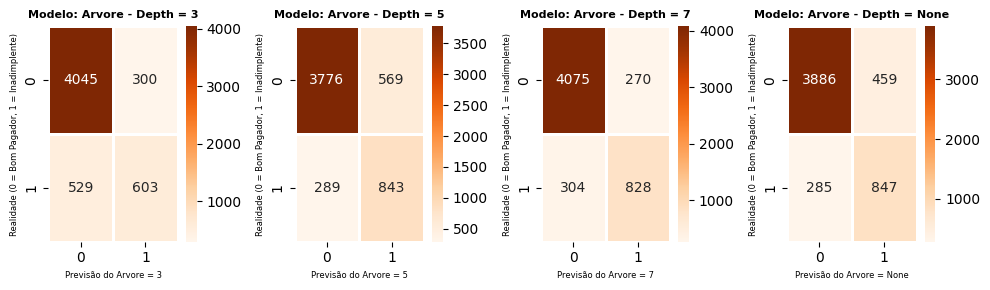

In [205]:
# Criando uma figura grande para colocar os dois gráficos lado a lado
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

# ---- Matriz da Arvore de Decisão - Max_depth = 3  ----
matriz_arvore_3 = confusion_matrix(y_teste, previsoes_arvore_3)
sns.heatmap(matriz_arvore_3, annot=True, fmt='d', cmap='Oranges', ax=axes[0], linewidths=1)
axes[0].set_title('Modelo: Arvore - Depth = 3', fontsize=8, fontweight='bold')
axes[0].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[0].set_xlabel('Previsão do Arvore = 3', fontsize=6)

# ---- Matriz da Arvore de Decisão - Max_depth = 5  ----
matriz_arvore_5 = confusion_matrix(y_teste, previsoes_arvore_5)
sns.heatmap(matriz_arvore_5, annot=True, fmt='d', cmap='Oranges', ax=axes[1], linewidths=1)
axes[1].set_title('Modelo: Arvore - Depth = 5', fontsize=8, fontweight='bold')
axes[1].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[1].set_xlabel('Previsão do Arvore = 5', fontsize=6)

# ---- Matriz da Arvore de Decisão - Max_depth = 7  ----
matriz_arvore_7 = confusion_matrix(y_teste, previsoes_arvore_7)
sns.heatmap(matriz_arvore_7, annot=True, fmt='d', cmap='Oranges', ax=axes[2], linewidths=1)
axes[2].set_title('Modelo: Arvore - Depth = 7', fontsize=8, fontweight='bold')
axes[2].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[2].set_xlabel('Previsão do Arvore = 7', fontsize=6)

# ---- Matriz da Arvore de Decisão - Max_depth = None  ----
matriz_arvore_none = confusion_matrix(y_teste, previsoes_arvore_none)
sns.heatmap(matriz_arvore_none, annot=True, fmt='d', cmap='Oranges', ax=axes[3], linewidths=1)
axes[3].set_title('Modelo: Arvore - Depth = None', fontsize=8, fontweight='bold')
axes[3].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[3].set_xlabel('Previsão do Arvore = None', fontsize=6)

# Ajustar o layout e exibir na tela
plt.tight_layout()
plt.show()

In [217]:
# Diagnóstico de overfitting — comparar treino vs teste
print("Treino:", classification_report(y_smote, arvore_model_7.predict(X_smote)))
print("Teste:", classification_report(y_teste, previsoes_arvore_7))

Treino:               precision    recall  f1-score   support

           0       0.82      0.94      0.88     17380
           1       0.93      0.80      0.86     17380

    accuracy                           0.87     34760
   macro avg       0.87      0.87      0.87     34760
weighted avg       0.87      0.87      0.87     34760

Teste:               precision    recall  f1-score   support

           0       0.93      0.94      0.93      4345
           1       0.75      0.73      0.74      1132

    accuracy                           0.90      5477
   macro avg       0.84      0.83      0.84      5477
weighted avg       0.89      0.90      0.89      5477



Resultado da Arvore de Decisão:

A arvore de decisão com profundidade de folha 7 retorna o melhor resultado pois teve uma acuracia de 90% e recall da classe 1 de 74%.

O recall de classe 1 do None é melhor mas esta gerando muitos falsos positivos (classifica bons pagadores como inadimplentes). Se você quer mais segurança é bom, mas vai deixar de dar credito pra quem poderia ser um bom pagador de juros.

Conclusão geral: Depth=7 encontrou o melhor equilíbrio. A árvore com profundidade irrestrita (None) começa a decorar o treino (overfitting), perdendo qualidade.

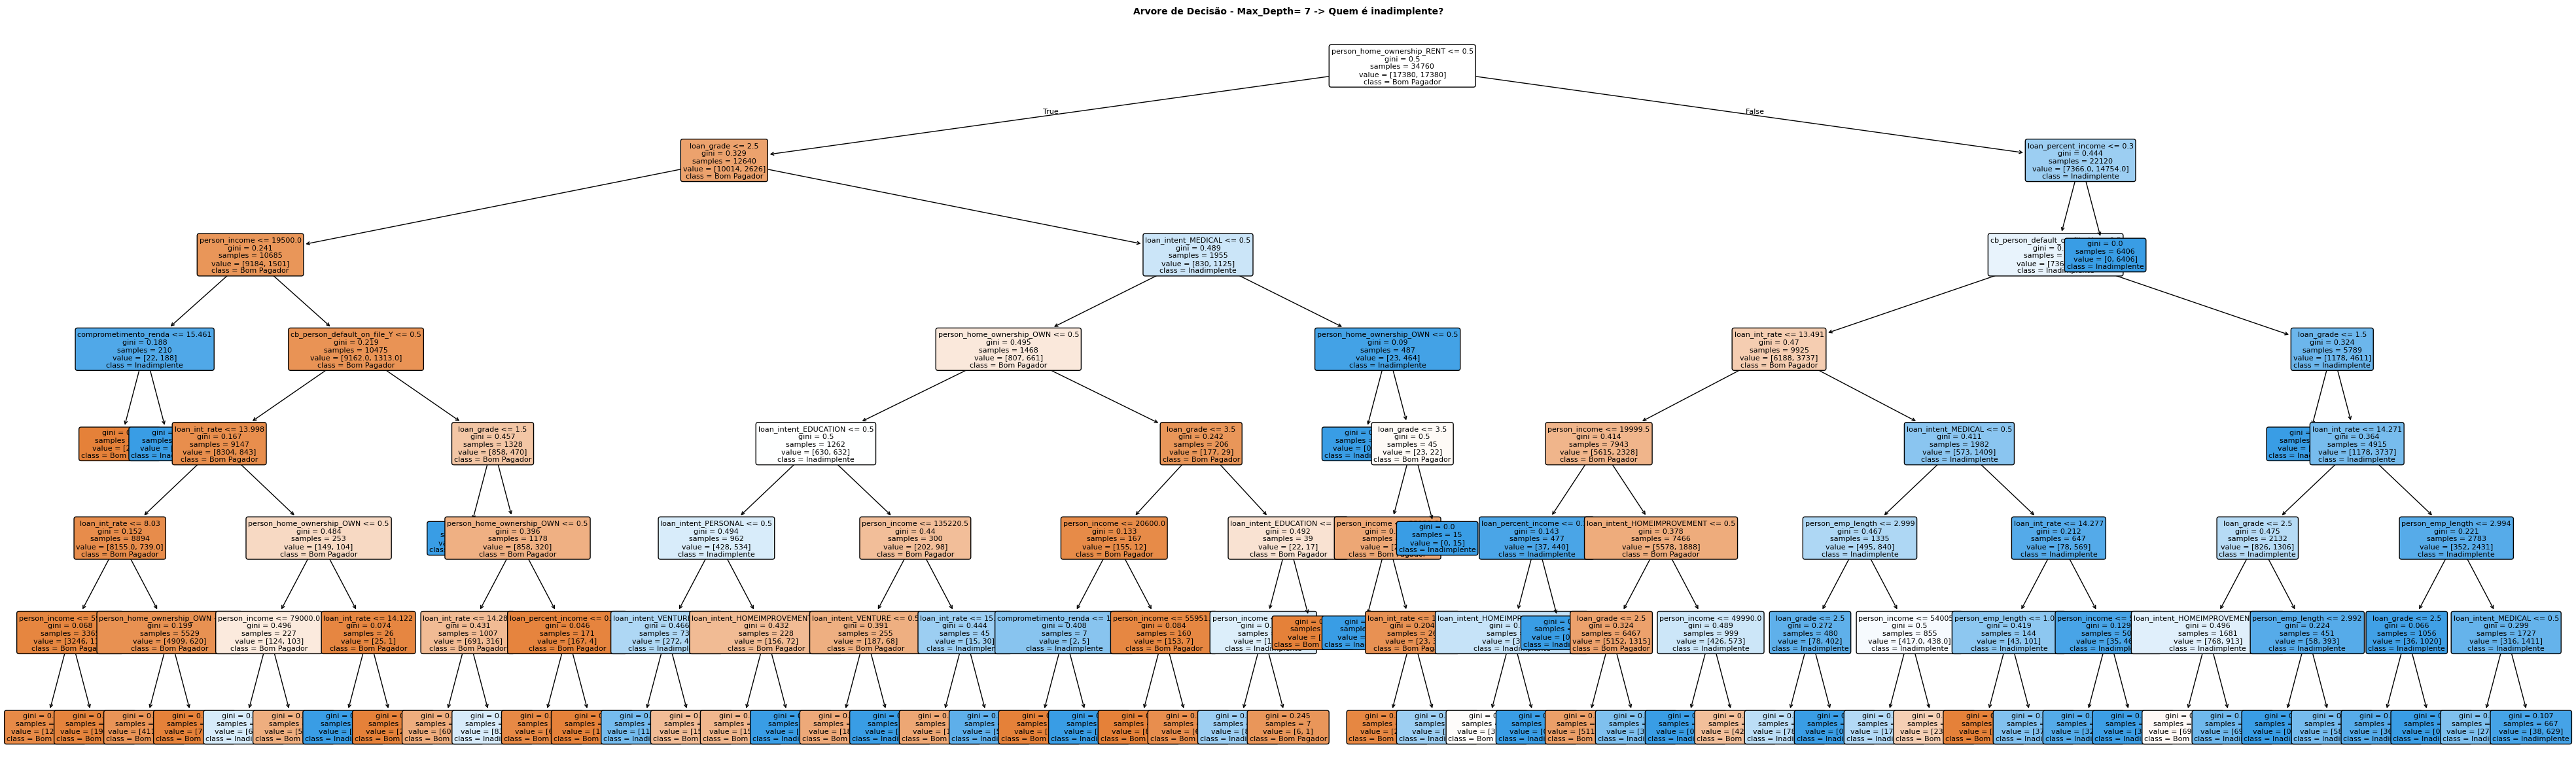

In [212]:
#Vamos desenhar as regras matemáticas do modelo da melhor Arvore
plt.figure(figsize=(50, 15))
plot_tree(
    arvore_model_7,
    feature_names=X.columns,
    class_names=['Bom Pagador', 'Inadimplente'],
    filled=True,         # Colore as caixinhas (laranja para inadimplentes, azul para bom pagador)
    rounded=True,
    fontsize=8
)
plt.title("Arvore de Decisão - Max_Depth= 7 -> Quem é inadimplente?", fontsize=10, fontweight='bold')
plt.show()

## Fase 6: Avaliação e Veredito de Negocios

Pegando o melhor dos dois modelos ficaria:
* KNN = 9
* Arvore de Decisão = 7


RELATÓRIO DE DESEMPENHO: KNN - K = 9
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      4345
           1       0.69      0.69      0.69      1132

    accuracy                           0.87      5477
   macro avg       0.81      0.80      0.80      5477
weighted avg       0.87      0.87      0.87      5477


RELATÓRIO DE DESEMPENHO: Arvore de Decisao - Max_depth = 7
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4345
           1       0.75      0.73      0.74      1132

    accuracy                           0.90      5477
   macro avg       0.84      0.83      0.84      5477
weighted avg       0.89      0.90      0.89      5477



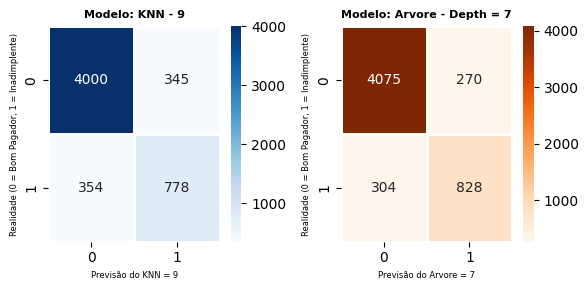

In [207]:
#Comparação resultados numéricos dos melhores modelos:
print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: KNN - K = 9")
print(classification_report(y_teste, previsoes_knn_9))

print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: Arvore de Decisao - Max_depth = 7")
print(classification_report(y_teste, previsoes_arvore_7))

# Gráficos dos melhores modelos:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# ---- Matriz do KNN 9 ----
matriz_knn_9 = confusion_matrix(y_teste, previsoes_knn_9)
sns.heatmap(matriz_knn_9, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=1)
axes[0].set_title('Modelo: KNN - 9', fontsize=8, fontweight='bold')
axes[0].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[0].set_xlabel('Previsão do KNN = 9', fontsize=6)

# ---- Matriz da Arvore de Decisão - Max_depth = 7  ----
matriz_arvore_7 = confusion_matrix(y_teste, previsoes_arvore_7)
sns.heatmap(matriz_arvore_7, annot=True, fmt='d', cmap='Oranges', ax=axes[1], linewidths=1)
axes[1].set_title('Modelo: Arvore - Depth = 7', fontsize=8, fontweight='bold')
axes[1].set_ylabel('Realidade (0 = Bom Pagador, 1 = Inadimplente)', fontsize=6)
axes[1].set_xlabel('Previsão do Arvore = 7', fontsize=6)

# Ajustar o layout e exibir na tela
plt.tight_layout()
plt.show()

Resultado Final:

A Árvore vence em todos os critérios. O ponto mais importante para crédito é o recall da classe 1 — a Árvore identifica 50 inadimplentes a mais que o KNN, o que em um cenário real representa menos prejuízo financeiro.
Além disso, a Árvore de Decisão tem uma vantagem prática extra: ela é interpretável — você consegue visualizar exatamente quais variáveis ela usou para tomar cada decisão, o que o KNN não oferece.

A Árvore Depth=7 teve 304 Falsos Negativos contra 354 do KNN-9 — ou seja, além de ser o melhor modelo geral, ela também comete menos o erro mais custoso.